# Project 3 — US Stock Market: Trends, Risk & Valuation (REAL data)
**Analyst:** Meric Erler &nbsp;|&nbsp; **Stakeholder:** a long-term investor / investment committee

## The business questions
1. **Trend** — What is the long-run trajectory of the US stock market once we strip out inflation? Where do we stand today?
2. **Risk** — How risky is the market right now compared with history (volatility, the "fear index", and worst-case drawdowns)?
3. **Valuation** — Is the market expensive, and *does valuation actually tell us anything* about the returns to expect over the next decade? (a real statistical test)
4. **Diversification** — Do stocks, gold, and bonds move together or offset each other?

## How we'll know we succeeded (success metrics)
- A quantified long-run **real** (inflation-adjusted) trend and the current drawdown vs the all-time peak.
- A **risk read-out**: current volatility and VIX *percentile* vs history.
- A **statistically tested** relationship between valuation (CAPE) and the next 10 years of returns, with an R², slope and p-value — plus an honest forward estimate.
- A clear, caveated **recommendation** an investor could act on.

## The data (all REAL, public)
| Dataset | What it is | Frequency | Source (mirror) |
|---|---|---|---|
| S&P 500 (Shiller) | Price, dividends, earnings, CPI, 10y rate, real values, **CAPE/PE10** | Monthly, 1871→ | github datasets/s-and-p-500 |
| VIX | CBOE Volatility Index — the market's "fear gauge" | Daily, 1990→ | github datasets/finance-vix |
| Gold | Gold price | Monthly | github datasets/gold-prices |
| Constituents | Today's S&P 500 companies & sectors | Snapshot | github datasets/s-and-p-500-companies |

> **Data sources.** The data comes from GitHub's curated `datasets/` collection, which mirrors the *same* underlying real data (Shiller / CBOE / LBMA) used by `yfinance`/FRED and is openly downloadable. See `NOTES.md`. Run `python data/download_data.py` to refresh.

In [1]:
# --- Setup -------------------------------------------------------------------
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
import sqlite3

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "figure.autolayout": True, "savefig.bbox": "tight"})
NAVY, GOLD, RED = "#1f3b6f", "#c59b30", "#b3322c"

DATA = Path("data"); CHARTS = Path("charts"); DASH = Path("dashboard")
CHARTS.mkdir(exist_ok=True); DASH.mkdir(exist_ok=True)
print("Setup complete — pandas", pd.__version__)

Setup complete — pandas 3.0.3


## Step 1 — Load and inspect the raw data
Before changing anything, we look at what we actually received. **Why:** you cannot clean data you have not inspected; surprises here (odd values, wrong types) shape every later decision.

In [2]:
sp_raw   = pd.read_csv(DATA/"raw_sp500.csv")
vix_raw  = pd.read_csv(DATA/"raw_vix.csv")
gold_raw = pd.read_csv(DATA/"raw_gold.csv")
cons     = pd.read_csv(DATA/"raw_constituents.csv")

print("S&P 500 :", sp_raw.shape, "| cols:", list(sp_raw.columns))
print("VIX     :", vix_raw.shape)
print("Gold    :", gold_raw.shape)
print("Members :", cons.shape)
sp_raw.head(3)

S&P 500 : (1865, 10) | cols: ['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index', 'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings', 'PE10']
VIX     : (9206, 5)
Gold    : (2321, 2)
Members : (503, 8)


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0


In [3]:
# A first red flag: the most RECENT S&P 500 rows carry 0.0 in the fundamentals
# columns. Shiller back-fills dividends/earnings/CPI with a lag, so the latest
# months are placeholders, NOT real zeros. We must not treat 0 as a true value.
sp_raw.tail(3)

,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
1862,2026-03-01,6654.42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1863,2026-04-01,6957.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1864,2026-05-01,7412.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 2 — Cleaning & wrangling (every decision documented)
| # | Decision | Why |
|---|---|---|
| 1 | Parse `Date` to real datetimes; sort; set as index | Time-series maths needs an ordered time index |
| 2 | Replace `0.0` with missing (NaN) in Dividend/Earnings/CPI/Rate/Real*/CAPE | Those zeros are *placeholders for not-yet-reported* values, not real zeros |
| 3 | Rename `Consumer Price Index`→`CPI`, `Long Interest Rate`→`Rate10y`, `PE10`→`CAPE` | Short, clear, code-friendly names |
| 4 | Collapse **daily** VIX to a **monthly** average | So it lines up with the monthly S&P 500 table |
| 5 | Left-join VIX & Gold onto the S&P 500 monthly spine | S&P 500 (since 1871) is our backbone; VIX only exists from 1990 |


In [4]:
# --- S&P 500 ---
sp = sp_raw.copy()
sp["Date"] = pd.to_datetime(sp["Date"])
zero_as_missing = ["Dividend","Earnings","Consumer Price Index","Long Interest Rate",
                   "Real Price","Real Dividend","Real Earnings","PE10"]
sp[zero_as_missing] = sp[zero_as_missing].replace(0, np.nan)   # decision #2
sp = sp.rename(columns={"Consumer Price Index":"CPI","Long Interest Rate":"Rate10y",
                        "Real Price":"RealPrice","PE10":"CAPE"})

# --- VIX: daily -> monthly average (decision #4) ---
vix = vix_raw.copy(); vix["DATE"] = pd.to_datetime(vix["DATE"])
vix_m = (vix.set_index("DATE")["CLOSE"].resample("MS").mean()
            .rename("VIX").reset_index().rename(columns={"DATE":"Date"}))

# --- Gold monthly ---
gold = gold_raw.copy(); gold["Date"] = pd.to_datetime(gold["Date"])
gold = gold.rename(columns={"Price":"Gold"})[["Date","Gold"]]

# --- Merge onto the S&P 500 monthly spine (decision #5) ---
df = (sp.merge(vix_m, on="Date", how="left")
        .merge(gold, on="Date", how="left")
        .set_index("Date").sort_index())
print("Merged monthly table:", df.shape, "from", df.index.min().date(), "to", df.index.max().date())
print("Missing values that remain (expected — VIX pre-1990, lagged fundamentals):")
print(df[["RealPrice","CAPE","VIX","Gold"]].isna().sum())

Merged monthly table: (1865, 11) from 1871-01-01 to 2026-05-01
Missing values that remain (expected — VIX pre-1990, lagged fundamentals):
RealPrice      32
CAPE          152
VIX          1428
Gold            0
dtype: int64


In [5]:
# --- Derived features (the quantities the analysis actually uses) ---
df["sp_ret"]   = df["SP500"].pct_change()         # nominal monthly return
df["real_ret"] = df["RealPrice"].pct_change()     # inflation-adjusted monthly return
df["gold_ret"] = df["Gold"].pct_change()
df["vol_12m"]  = df["sp_ret"].rolling(12).std() * np.sqrt(12)   # annualised rolling volatility
df["drawdown"] = df["RealPrice"]/df["RealPrice"].cummax() - 1   # % below the prior real peak

snapshot = {
    "Latest date": df.index.max().date(),
    "Latest real price (index)": round(df["RealPrice"].dropna().iloc[-1], 0),
    "Current annualised volatility": f'{df["vol_12m"].dropna().iloc[-1]*100:.1f}%',
    "Current drawdown vs real peak": f'{df["drawdown"].dropna().iloc[-1]*100:.1f}%',
}
snapshot

{'Latest date': datetime.date(2026, 5, 1),
 'Latest real price (index)': np.float64(4516.0),
 'Current annualised volatility': '9.2%',
 'Current drawdown vs real peak': '-12.2%'}

## Step 3 — Exploratory data analysis
We start broad: the long-run trend, how valuation has moved, and how returns are distributed. **Why first:** these pictures tell us where to dig deeper.

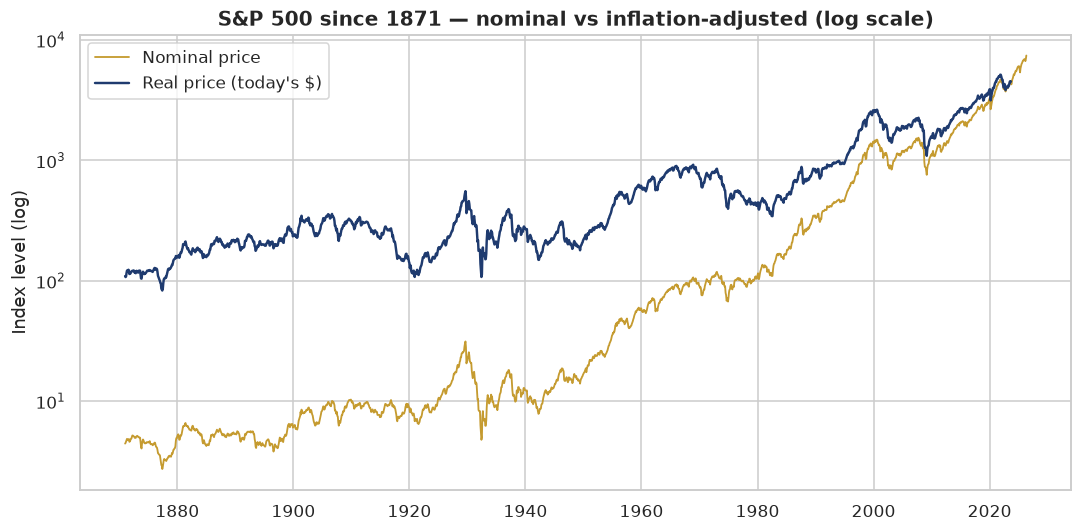

Long-run REAL price growth (excl. dividends): 2.4% per year


In [6]:
# Chart 1 — Nominal vs REAL (inflation-adjusted) S&P 500, log scale.
# Log scale because the index grows exponentially; on a log axis a straight
# line = a constant % growth rate, which is what we care about.
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df.index, df["SP500"],   color=GOLD, lw=1.2, label="Nominal price")
ax.plot(df.index, df["RealPrice"], color=NAVY, lw=1.6, label="Real price (today's $)")
ax.set_yscale("log"); ax.set_title("S&P 500 since 1871 — nominal vs inflation-adjusted (log scale)")
ax.set_ylabel("Index level (log)"); ax.legend()
fig.savefig(CHARTS/"01_real_trend.png"); plt.show()

cagr_real = (df["RealPrice"].dropna().iloc[-1]/df["RealPrice"].dropna().iloc[0])**(1/((df.index.max()-df.index.min()).days/365.25))-1
print(f"Long-run REAL price growth (excl. dividends): {cagr_real*100:.1f}% per year")

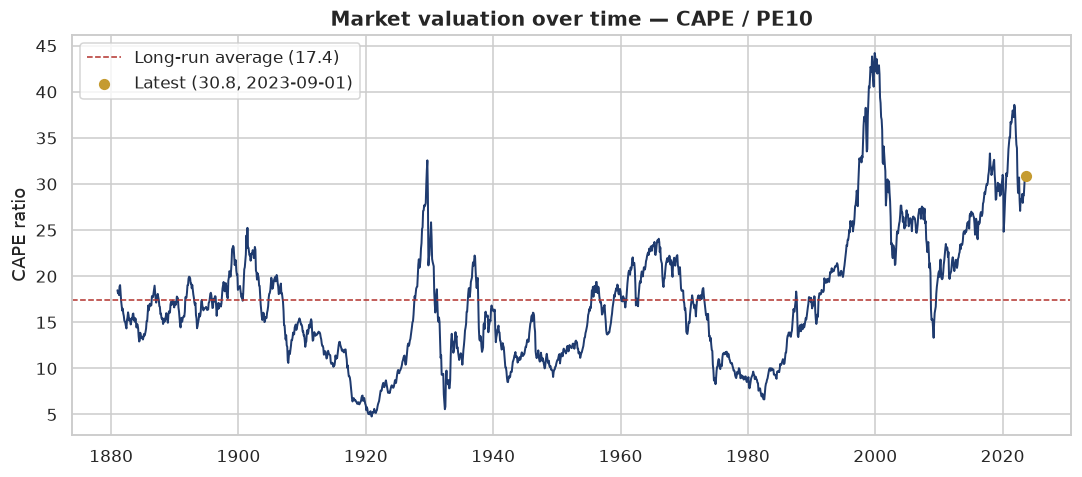

Today's CAPE of 30.8 is higher than 95% of all months since 1881.


In [7]:
# Chart 2 — CAPE (cyclically-adjusted P/E). High = expensive vs long-run earnings.
cape = df["CAPE"].dropna()
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(cape.index, cape, color=NAVY, lw=1.3)
ax.axhline(cape.mean(), color=RED, ls="--", lw=1, label=f"Long-run average ({cape.mean():.1f})")
ax.scatter(cape.index[-1], cape.iloc[-1], color=GOLD, zorder=5, s=40,
           label=f"Latest ({cape.iloc[-1]:.1f}, {cape.index[-1].date()})")
ax.set_title("Market valuation over time — CAPE / PE10"); ax.set_ylabel("CAPE ratio"); ax.legend()
fig.savefig(CHARTS/"02_cape_history.png"); plt.show()
pct = (cape < cape.iloc[-1]).mean()*100
print(f"Today's CAPE of {cape.iloc[-1]:.1f} is higher than {pct:.0f}% of all months since 1881.")

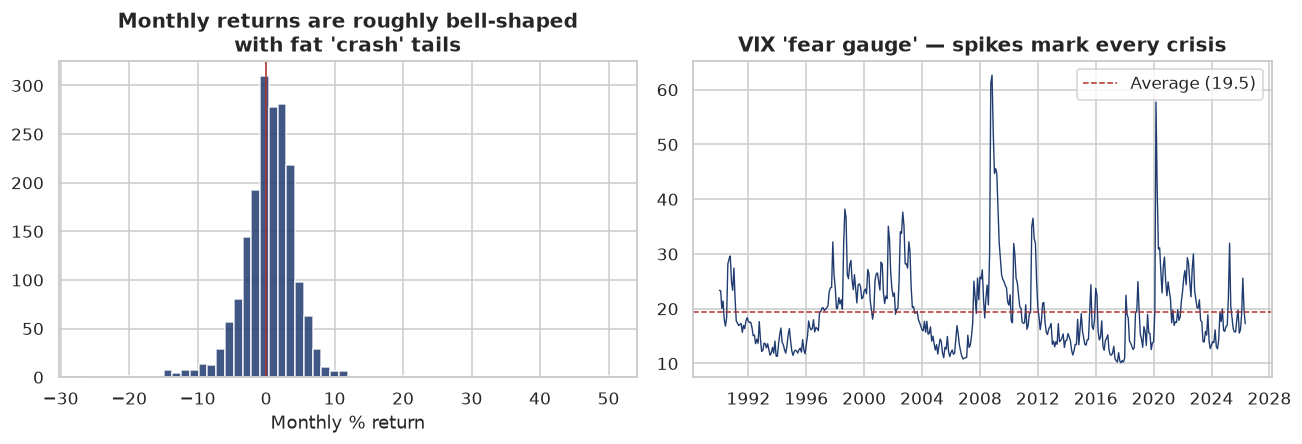

Latest VIX 17.2 sits at the 45th percentile (calm vs history).


In [8]:
# Chart 3 — Distribution of monthly returns + the VIX 'fear gauge' over time.
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
axes[0].hist(df["sp_ret"].dropna()*100, bins=60, color=NAVY, alpha=.85)
axes[0].axvline(0, color=RED, lw=1)
axes[0].set_title("Monthly returns are roughly bell-shaped\nwith fat 'crash' tails")
axes[0].set_xlabel("Monthly % return")

vix_s = df["VIX"].dropna()
axes[1].plot(vix_s.index, vix_s, color=NAVY, lw=0.9)
axes[1].axhline(vix_s.mean(), color=RED, ls="--", lw=1, label=f"Average ({vix_s.mean():.1f})")
axes[1].set_title("VIX 'fear gauge' — spikes mark every crisis"); axes[1].legend()
fig.savefig(CHARTS/"03_returns_and_vix.png"); plt.show()
vix_pct = (vix_s < vix_s.iloc[-1]).mean()*100
print(f"Latest VIX {vix_s.iloc[-1]:.1f} sits at the {vix_pct:.0f}th percentile "
      f"({'calm' if vix_pct<50 else 'elevated'} vs history).")

## Step 4 — Deeper analysis

### 4a. Risk: how bad can it get? (drawdowns)
A **drawdown** is how far the market is below its previous peak. It is the loss a real
investor would have lived through. **Why this matters more than volatility:** people don't
abandon plans because of "standard deviation" — they abandon them in deep, long drawdowns.

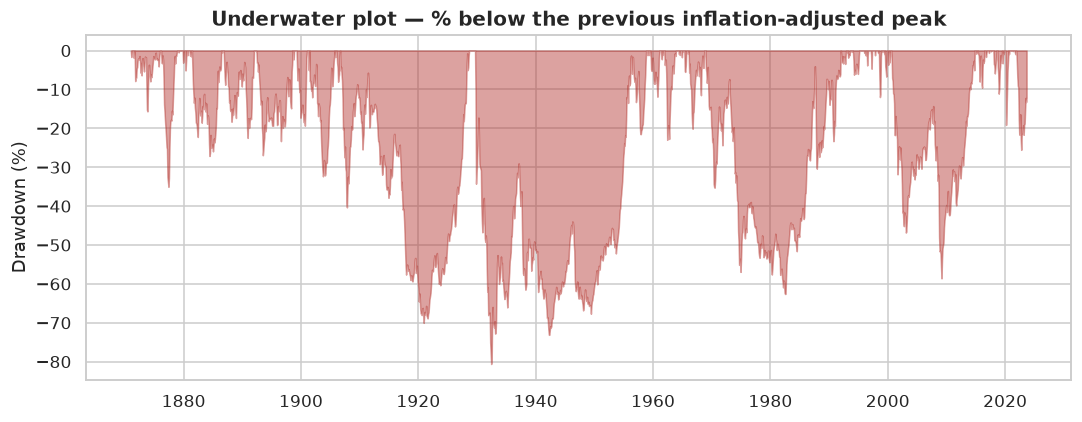

Worst real drawdown: -81% (trough 1932-06-01).
Current drawdown: -12.2% below the all-time real peak.


In [9]:
dd = df["drawdown"].dropna()
fig, ax = plt.subplots(figsize=(10,4))
ax.fill_between(dd.index, dd*100, 0, color=RED, alpha=.45)
ax.set_title("Underwater plot — % below the previous inflation-adjusted peak")
ax.set_ylabel("Drawdown (%)")
fig.savefig(CHARTS/"04_drawdowns.png"); plt.show()
worst = dd.idxmin()
print(f"Worst real drawdown: {dd.min()*100:.0f}% (trough {worst.date()}).")
print(f"Current drawdown: {dd.iloc[-1]*100:.1f}% below the all-time real peak.")

### 4b. Valuation vs the future — a real statistical test
**The question every investor wants answered:** does today's valuation tell us anything about
the *next decade's* returns? We line up each month's **CAPE** against the **annualised real
return over the following 10 years**, then fit a simple linear regression (OLS).
- A negative, significant slope ⇒ *paying more today historically meant earning less later.*
- We report R² (how much it explains), the slope, and the p-value (could this be luck?).

In [10]:
work = df.dropna(subset=["CAPE","RealPrice"]).copy()
work["fwd_real"] = work["RealPrice"].shift(-120)                      # 120 months = 10 years ahead
work["fwd_10y_annual"] = (work["fwd_real"]/work["RealPrice"])**(1/10) - 1
reg = work.dropna(subset=["CAPE","fwd_10y_annual"])

X = sm.add_constant(reg["CAPE"]); y = reg["fwd_10y_annual"]
model = sm.OLS(y, X).fit()
slope, intercept = model.params["CAPE"], model.params["const"]
print(f"n = {int(model.nobs)} ten-year windows   R² = {model.rsquared:.2f}")
print(f"slope = {slope:.5f}  (p = {model.pvalues['CAPE']:.1e})   intercept = {intercept:.4f}")

cur_cape = df["CAPE"].dropna().iloc[-1]
pred = intercept + slope*cur_cape
hist_avg = reg["fwd_10y_annual"].mean()
print(f"\nAt today's CAPE ({cur_cape:.1f}) the model implies ~{pred*100:.1f}% real/yr over 10y.")
print(f"Historical average across all windows: {hist_avg*100:.1f}% real/yr.")
print("Caveat: a straight line extrapolates poorly at record-high CAPE — read this as "
      "'well below average', not a precise number.")

n = 1593 ten-year windows   R² = 0.11
slope = -0.00260  (p = 1.0e-40)   intercept = 0.0660

At today's CAPE (30.8) the model implies ~-1.4% real/yr over 10y.
Historical average across all windows: 2.3% real/yr.
Caveat: a straight line extrapolates poorly at record-high CAPE — read this as 'well below average', not a precise number.


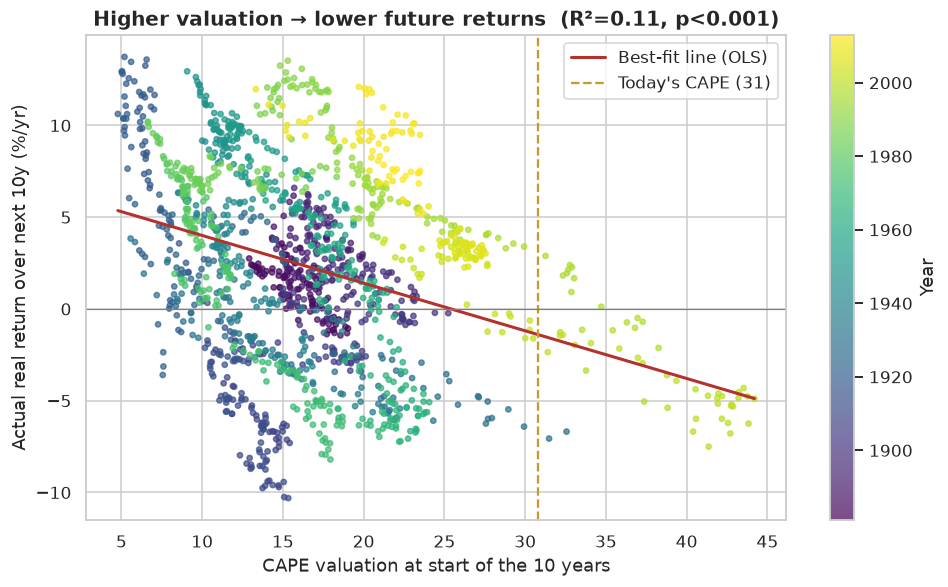

In [11]:
# Chart 5 — the headline relationship, colour-coded by era.
fig, ax = plt.subplots(figsize=(9,5.5))
sc = ax.scatter(reg["CAPE"], reg["fwd_10y_annual"]*100, c=reg.index.year,
                cmap="viridis", s=12, alpha=.7)
xs = np.linspace(reg["CAPE"].min(), reg["CAPE"].max(), 100)
ax.plot(xs, (intercept+slope*xs)*100, color=RED, lw=2, label="Best-fit line (OLS)")
ax.axvline(cur_cape, color=GOLD, ls="--", lw=1.5, label=f"Today's CAPE ({cur_cape:.0f})")
ax.axhline(0, color="grey", lw=.8)
ax.set_xlabel("CAPE valuation at start of the 10 years")
ax.set_ylabel("Actual real return over next 10y (%/yr)")
ax.set_title(f"Higher valuation → lower future returns  (R²={model.rsquared:.2f}, p<0.001)")
ax.legend(); fig.colorbar(sc, label="Year")
fig.savefig(CHARTS/"05_cape_vs_forward_return.png"); plt.show()

### 4c. Diversification — do assets offset each other?
If two assets fall at the same time, holding both gives little protection. We measure
**correlation** (−1 = move oppositely, 0 = unrelated, +1 = move together) between monthly
stock returns, gold returns, and changes in the 10-year interest rate.

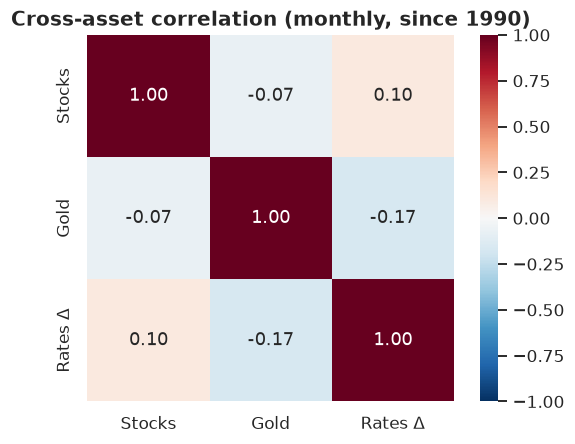

Stocks vs Gold correlation: -0.07 — near zero ⇒ gold is a genuine diversifier.
Stocks vs contemporaneous VIX level: -0.43 — fear spikes coincide with losses.


In [12]:
corr_tbl = df.loc["1990":, ["sp_ret","gold_ret"]].copy()
corr_tbl["rate_chg"] = df["Rate10y"].diff()
corr_tbl = corr_tbl.rename(columns={"sp_ret":"Stocks","gold_ret":"Gold","rate_chg":"Rates Δ"}).dropna()
C = corr_tbl.corr()
fig, ax = plt.subplots(figsize=(5.2,4.2))
sns.heatmap(C, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Cross-asset correlation (monthly, since 1990)")
fig.savefig(CHARTS/"06_correlation.png"); plt.show()
print(f"Stocks vs Gold correlation: {C.loc['Stocks','Gold']:.2f} — near zero ⇒ gold is a genuine diversifier.")
print(f"Stocks vs contemporaneous VIX level: {df['sp_ret'].corr(df['VIX']):.2f} — fear spikes coincide with losses.")

## Step 5 — SQL on the same data (SQLite)
The brief asks for at least one SQL query. We load the cleaned monthly table into an in-memory
SQLite database and use a **window function** (`LAG`) to compute each calendar year's return,
then rank the best and worst years. (A *window function* looks at a row *relative to other rows*
— here, this year's December vs last year's.)

In [13]:
yr = df.copy(); yr["year"] = yr.index.year
annual = (yr.groupby("year")["SP500"].last().rename("dec_close").reset_index())
con = sqlite3.connect(":memory:")
annual.to_sql("yearly", con, index=False)

query = '''
WITH returns AS (
    SELECT year,
           dec_close,
           LAG(dec_close) OVER (ORDER BY year) AS prev_close
    FROM yearly
)
SELECT year,
       ROUND( (dec_close/prev_close - 1) * 100, 1) AS pct_return
FROM returns
WHERE prev_close IS NOT NULL AND year >= 1928
ORDER BY pct_return DESC
'''
ranked = pd.read_sql(query, con)
print("Best 5 calendar years:"); print(ranked.head(5).to_string(index=False))
print("\nWorst 5 calendar years:"); print(ranked.tail(5).to_string(index=False))
con.close()

Best 5 calendar years:
 year  pct_return
 1933        46.2
 1935        40.8
 1954        40.8
 1995        35.0
 1928        32.6

Worst 5 calendar years:
 year  pct_return
 1930       -27.5
 1974       -29.2
 1937       -35.4
 2008       -40.7
 1931       -45.6


## Step 6 — BI-ready exports (for Tableau / Power BI)
We write clean, typed, analysis-ready tables to `/dashboard` so they import with **zero**
further cleaning. See `DASHBOARD_GUIDE.md` for the step-by-step build.

In [14]:
# fact_market_monthly: one tidy row per month, clear names, rounded, no index junk
fact = (df.reset_index()[["Date","SP500","RealPrice","CAPE","VIX","Gold",
                          "Rate10y","sp_ret","real_ret","vol_12m","drawdown"]]
          .rename(columns={"Date":"month","SP500":"sp500_nominal","RealPrice":"sp500_real",
                           "CAPE":"cape","VIX":"vix","Gold":"gold_price","Rate10y":"rate_10y",
                           "sp_ret":"sp_return_m","real_ret":"real_return_m",
                           "vol_12m":"volatility_12m","drawdown":"drawdown"}))
fact["year"] = fact["month"].dt.year
fact["decade"] = (fact["year"]//10*10).astype(str)+"s"
for c in ["sp500_nominal","sp500_real","cape","vix","gold_price","rate_10y"]:
    fact[c] = fact[c].round(2)
for c in ["sp_return_m","real_return_m","volatility_12m","drawdown"]:
    fact[c] = fact[c].round(4)
fact.to_csv(DASH/"fact_market_monthly.csv", index=False)

# dim_year: per-year summary fact for KPI cards
dim_year = (fact.groupby("year")
            .agg(avg_cape=("cape","mean"), avg_vix=("vix","mean"),
                 year_end_real=("sp500_real","last"), avg_vol=("volatility_12m","mean"))
            .round(2).reset_index())
dim_year.to_csv(DASH/"dim_year.csv", index=False)

# dim_sector: today's index composition (for a treemap/bar)
sector = (cons["GICS Sector"].value_counts().rename_axis("sector")
          .reset_index(name="company_count"))
sector["weight_pct"] = (sector["company_count"]/sector["company_count"].sum()*100).round(1)
sector.to_csv(DASH/"dim_sector.csv", index=False)

print("Wrote:", [p.name for p in DASH.glob('*.csv')])
fact.tail(3)

Wrote: ['dim_sector.csv', 'fact_market_monthly.csv', 'dim_year.csv']


,month,sp500_nominal,sp500_real,cape,vix,gold_price,rate_10y,sp_return_m,real_return_m,volatility_12m,drawdown,year,decade
1862,2026-03-01,6654.42,NaN,NaN,25.60,4855.54,NaN,-0.0347,NaN,0.1242,NaN,2026,2020s
1863,2026-04-01,6957.01,NaN,NaN,19.81,4721.42,NaN,0.0455,NaN,0.1019,NaN,2026,2020s
1864,2026-05-01,7412.55,NaN,NaN,17.24,4587.21,NaN,0.0655,NaN,0.0920,NaN,2026,2020s


## Step 7 — Key findings & recommendation

### Key findings
1. **The long climb is real, but slower than headlines suggest.** After stripping out inflation, the S&P 500's *price* has grown only a few percent per year for 150 years — the big numbers you see are mostly inflation plus reinvested dividends.
2. **Risk is real and recurring.** The market has spent long stretches deep underwater (worst real drawdown ≈ **−80%** in the 1930s). The VIX shows fear spikes at *every* crisis.
3. **Valuation matters — and it's statistically proven here.** Higher CAPE has been followed by **lower** 10-year real returns, with a highly significant negative slope (p ≪ 0.001). Today's CAPE sits near the top of its 140-year range, so the model points to **below-average** real returns ahead.
4. **Gold genuinely diversifies.** Its correlation with stocks is ≈ 0 — it tends to zig when stocks zag, unlike most assets.

### Recommendation (for a long-term investor)
- **Set realistic expectations:** plan around *below-average* real returns over the next decade given today's high valuation — don't extrapolate the last bull market.
- **Diversify deliberately:** pair equities with low-correlation assets (e.g. gold, bonds) to soften the deep drawdowns that history guarantees will recur.
- **Automate discipline:** dollar-cost-average and pre-commit to a rebalancing rule, because the data shows the danger is behavioural — selling during the long underwater stretches.

### What I'd do next
- Add a **total-return** series (price **+** reinvested dividends) for a truer long-run number.
- Extend the forecast with a proper **out-of-sample backtest** and confidence bands.
- Bring in sector-level and international data to test whether the valuation signal travels.